In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.data.data import get_ds

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [51]:
class Encoder(nn.Module):
    def __init__(self, seq_len, input_size, encoding_size):
        super().__init__()
        self.seq_len = seq_len
        self.input_size = input_size
        self.encoding_size = encoding_size

        self.lstm1 = nn.LSTM(
            input_size=self.input_size,
            hidden_size=self.encoding_size,
            num_layers=2,
            batch_first=True
        )

        self.linear = nn.Linear(self.encoding_size, self.encoding_size)

    def forward(self, x):
        x, (hidden, cell) = self.lstm1(x)
        out = hidden[-1, :, :]
        # out = self.linear(out)
        return out
        
class Decoder(nn.Module):
    def __init__(self, seq_len, encoding_size, output_size):
        super().__init__()
        self.seq_len = seq_len
        self.encoding_size = encoding_size
        self.output_size = output_size

        self.lstm1 = nn.LSTM(
            input_size=self.encoding_size,
            hidden_size=2*self.encoding_size,
            num_layers=2,
            batch_first=True
        )

        self.linear = nn.Linear(2*self.encoding_size, self.output_size)

    def forward(self, x):
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, (hidden, cell) = self.lstm1(x)
        out = self.linear(x)
        return out

In [52]:
class Autoencoder(nn.Module):
    def __init__(self, seq_len, input_size, encoding_size):
        super().__init__()

        self.seq_len = seq_len
        self.input_size = input_size
        self.encoding_size = encoding_size

        self.encoder = Encoder(self.seq_len, self.input_size, self.encoding_size)
        self.decoder = Decoder(self.seq_len, self.encoding_size, self.input_size)

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded
    
    def encode(self, x):
        out = self.encoder(x)
        return out
    def decode(self, x):
        out = self.decoder(x)
        return out
    
    def train(self, epochs, learning_rate, gamma, data):
        opt = torch.optim.Adam(self.parameters(), learning_rate)
        sched = torch.optim.lr_scheduler.ExponentialLR(opt, gamma)
        loss_fn = torch.nn.MSELoss()

        for epoch in range(epochs):
            opt.zero_grad()

            encoded, decoded = self(data)
            loss = loss_fn(decoded, data)

            loss.backward()
            opt.step()

            print(f"Epoch: {epoch}, Loss: {float(loss)}")

In [53]:
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}

train_ds, test_ds = get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [54]:
autoencoder = Autoencoder(
    seq_len=100,
    input_size=1,
    encoding_size=10
)

In [55]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), True)
for data_matrix, labels in data_load:
    accel_x = data_matrix[:, :, 0]
    accel_x = accel_x.unsqueeze(2)
    autoencoder.train(epochs=2000, learning_rate=0.01, gamma=0.999, data=accel_x.float())


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Epoch: 0, Loss: 56.551116943359375
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Epoch: 1, Loss: 55.935218811035156
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Epoch: 2, Loss: 55.395179748535156
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI 

torch.Size([40, 10]) torch.Size([40, 100])


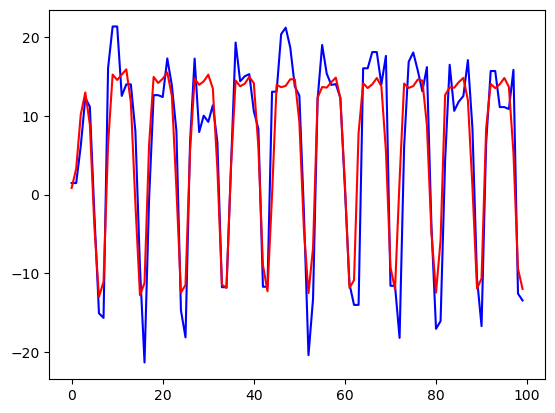

In [60]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), False)
for data_matrix, labels in data_load:
    accel_x = data_matrix[:, :, 0].unsqueeze(2).float()
    with torch.no_grad():
        encoded, decoded = autoencoder(accel_x)
        decoded = decoded.squeeze()
        print(encoded.size(), decoded.size())

        p1 = accel_x[13].squeeze()
        p2 = decoded[13]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.show()




In [35]:
from src.visualizations.umap_visualizer import UMAPLatent

/Users/bhaveshkalisetti/opt/anaconda3/envs/venv/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bhaveshkalisetti/opt/anaconda3/envs/venv/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bhaveshkalisetti/opt/anaconda3/envs/ven

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


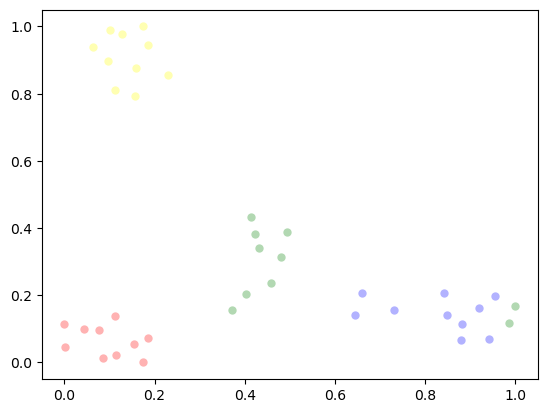

In [61]:
visualizer = UMAPLatent()
visualizer.visualize(encoded, labels, class_to_index)